In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
from utils import DATA_DIR
import logging
logging.getLogger().setLevel(logging.INFO)
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from arch import arch_model
import numpy as np
import pandas as pd
from modern_backtrader.data_feeds import DataFeeds
from modern_backtrader.state_manager import StateManager
import tushare as ts
from joblib import Parallel, delayed
from sklearn.linear_model import HuberRegressor

load_dotenv()
DATA_DIR.mkdir(parents=True, exist_ok=True)

DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/root/miniconda3/envs/quant/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Bold.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/root/miniconda3/envs/quant/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-BoldOblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 1.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/root/miniconda3/envs/quant/li

Text(0, 0.5, 'Cum Return')

DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/root/miniconda3/envs/quant/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Bold.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/root/miniconda3/envs/quant/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-BoldOblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 1.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/root/miniconda3/envs/quant/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/cmb10.ttf', name='cmb10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_m

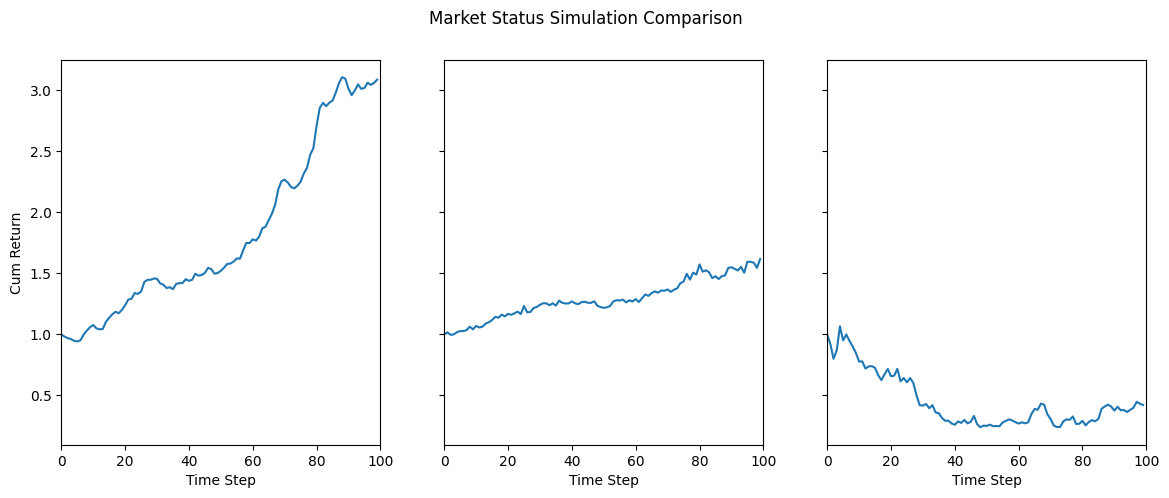

In [2]:
def create_ar1_generator(mu, rho, n_periods=100):
    np.random.seed(42)
    def generate(sigma_callback=lambda i : 0.02):
        rtn = np.random.randn(n_periods)
        rtn[0] = mu / (1 - rho)

        for i in range(1, n_periods):
            epsilon = np.random.normal(0, sigma_callback(i))
            rtn[i] = mu + rho * rtn[i - 1] + epsilon
        prices = np.exp(np.cumsum(rtn))
        prices = prices / prices[0]
        return rtn, prices
    return generate

generator_1 = create_ar1_generator(0.005, 0.5)
generator_2 = create_ar1_generator(0.005, -0.5)
generator_3 = create_ar1_generator(0.005, 0.1)

_, prices_1 = generator_1()
_, prices_2 = generator_2()
_, prices_3 = generator_3(sigma_callback=lambda i: 0.1)
prices_lst = [prices_1, prices_2, prices_3]

fig1, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True, sharex=True)
fig1.suptitle('Market Status Simulation Comparison')
for i in range(3):
    axes[i].plot(prices_lst[i])
    axes[i].set_xlabel('Time Step')
    axes[i].set_xlim([0, 100])
axes[0].set_ylabel('Cum Return')

Text(0.5, 0, 'Time Step')

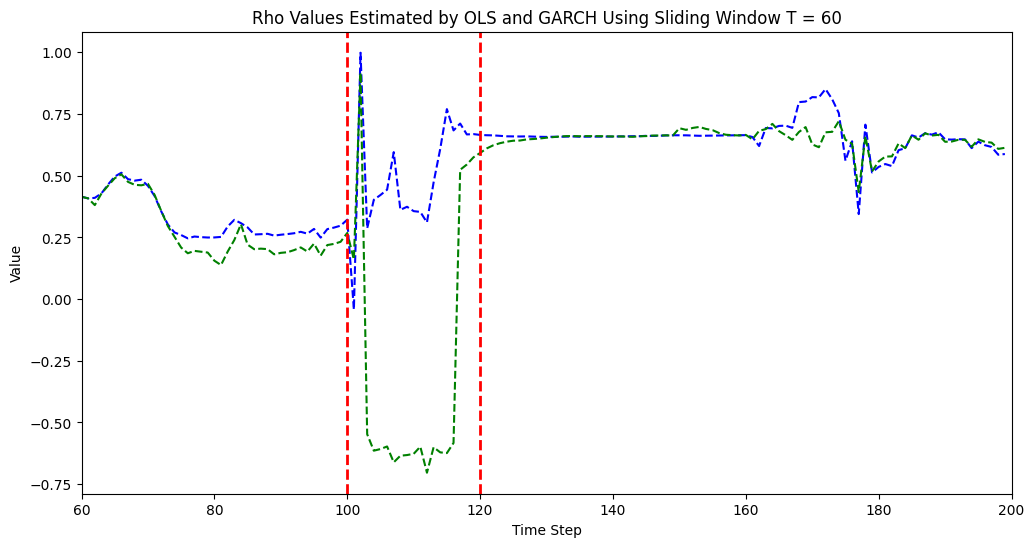

In [3]:
generator = create_ar1_generator(0.005, 0.5, 200)
rtns, _ = generator(lambda i: 0.5 if 100 < i < 120 else 0.02)
rtns_scaled = 100 * rtns

window_size, step_size = 60, 1
rolling_params = []
for i in range(window_size, len(rtns), step_size):
    X = rtns[i -window_size: i]
    y = rtns[i -window_size + 1: i + 1]

    X_with_const = sm.add_constant(X)
    OLS_model = OLS(y, X_with_const).fit()
    GARCH_model = arch_model(
        rtns_scaled[i - window_size: i + 1],
        mean='AR',
        lags=1,
        vol="GARCH",
        p=1,
        q=1
    ).fit(disp='off')

    rolling_params.append({
        'time': i,
        'OLS_rho': OLS_model.params[1],
        'GARCH_rho': GARCH_model.params.iloc[1],
    })

plt.figure(figsize=(12, 6))

times = [p['time'] for p in rolling_params]
OLS_rhos = [p['OLS_rho'] for p in rolling_params]
GARCH_rhos = [p['GARCH_rho'] for p in rolling_params]

plt.plot(times, OLS_rhos, '--b')
plt.plot(times, GARCH_rhos, '--g')
plt.axvline(x=100, color='red', linestyle='--', linewidth=2)
plt.axvline(x=120, color='red', linestyle='--', linewidth=2)
plt.xlim(times[0], len(rtns))
plt.title(f"Rho Values Estimated by OLS and GARCH Using Sliding Window T = {window_size}")
plt.ylabel('Value')
plt.xlabel('Time Step')

In [4]:
pro = ts.pro_api(os.getenv('TUSHARE_PRO_KEY'))
df = pro.fund_daily(
    ts_code='510300.SH',
    start_date='20150101',
    end_date='20260101',
    fields=[
        'ts_code',
        'trade_date',
        'pre_close',
        'open',
        'high',
        'low',
        'close',
        'change',
        'pct_chg',
        'vol',
        'amount'
    ]
)

df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.set_index('trade_date', drop=True)
df = df.sort_index()

feeds = DataFeeds(df, backtest_start='2020-01-01', backtest_end='2026-01-01')
state = StateManager.from_datafeeds(feeds)

DEBUG:urllib3.connectionpool:Starting new HTTP connection (1): api.waditu.com:80
DEBUG:urllib3.connectionpool:http://api.waditu.com:80 "POST /dataapi/fund_daily HTTP/1.1" 200 None
DEBUG:root:Cursor position: 1219


DEBUG:root:Cursor moved to 1219 (date: 2020-01-02 00:00:00)
DEBUG:root:Cursor moved to 1220 (date: 2020-01-03 00:00:00)
DEBUG:root:Cursor moved to 1221 (date: 2020-01-06 00:00:00)
DEBUG:root:Cursor moved to 1222 (date: 2020-01-07 00:00:00)
DEBUG:root:Cursor moved to 1223 (date: 2020-01-08 00:00:00)
DEBUG:root:Cursor moved to 1224 (date: 2020-01-09 00:00:00)
DEBUG:root:Cursor moved to 1225 (date: 2020-01-10 00:00:00)
DEBUG:root:Cursor moved to 1226 (date: 2020-01-13 00:00:00)
DEBUG:root:Cursor moved to 1227 (date: 2020-01-14 00:00:00)
DEBUG:root:Cursor moved to 1228 (date: 2020-01-15 00:00:00)
DEBUG:root:Cursor moved to 1229 (date: 2020-01-16 00:00:00)
DEBUG:root:Cursor moved to 1230 (date: 2020-01-17 00:00:00)
DEBUG:root:Cursor moved to 1231 (date: 2020-01-20 00:00:00)
DEBUG:root:Cursor moved to 1232 (date: 2020-01-21 00:00:00)
DEBUG:root:Cursor moved to 1233 (date: 2020-01-22 00:00:00)
DEBUG:root:Cursor moved to 1234 (date: 2020-01-23 00:00:00)
DEBUG:root:Cursor moved to 1235 (date: 2

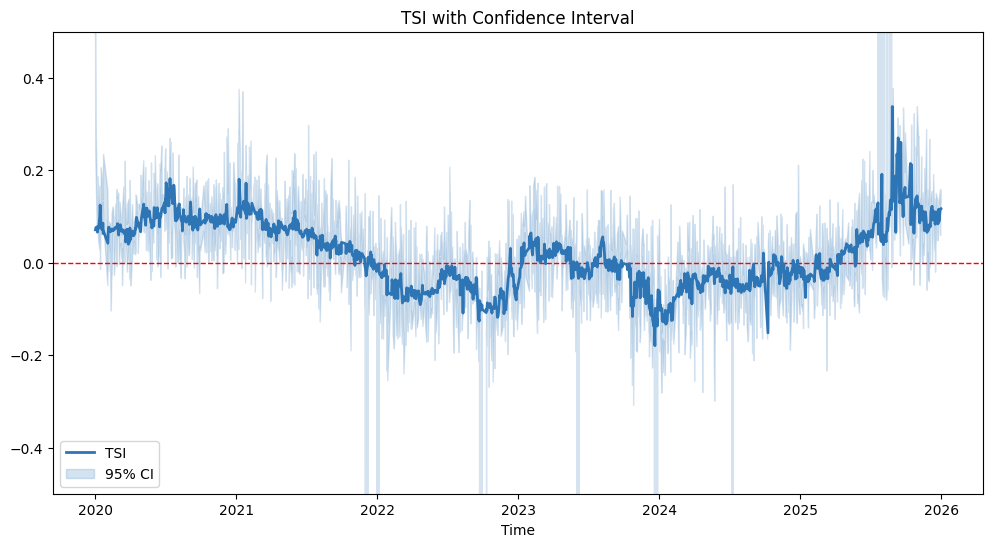

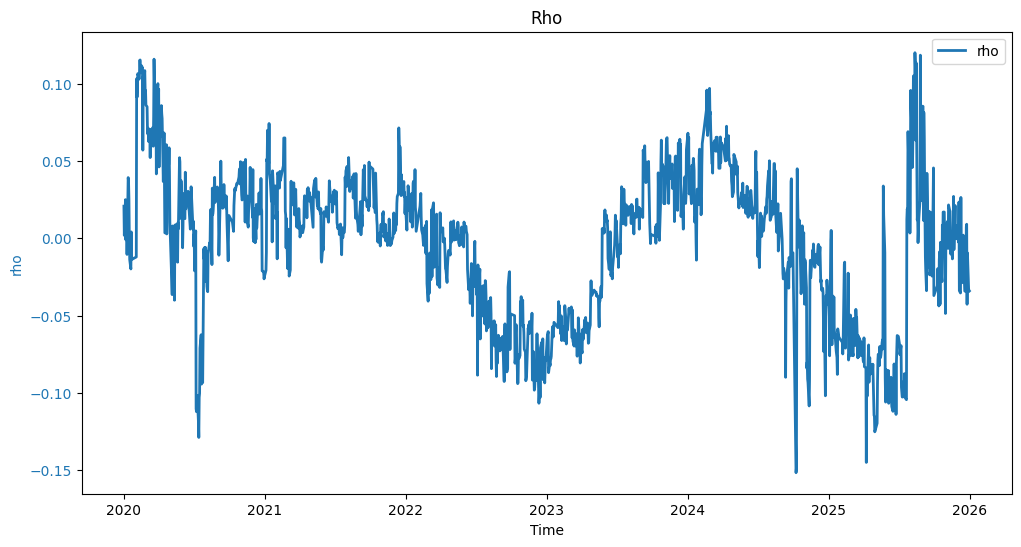

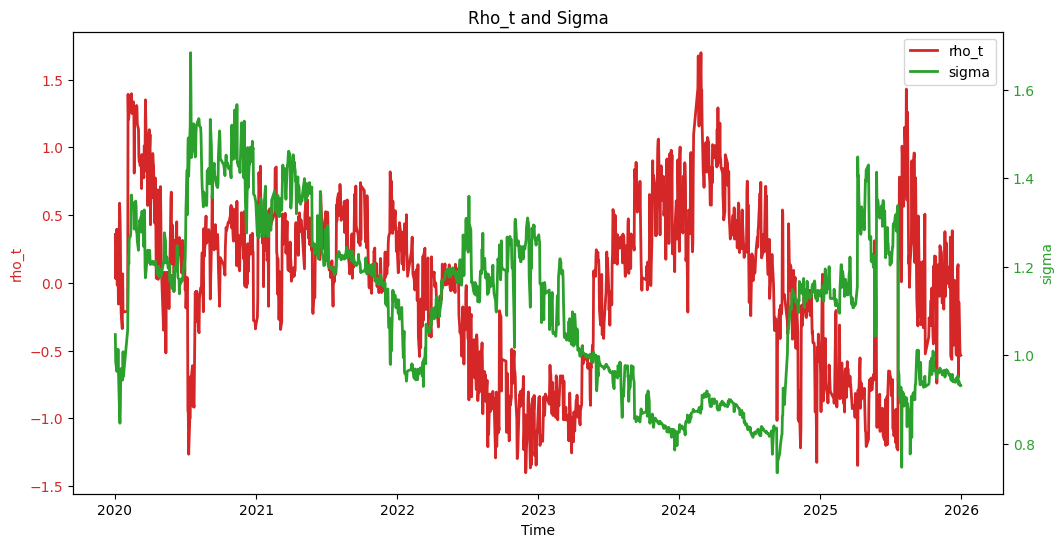

In [5]:
window_lower, window_upper = 21, 250
cache_path = DATA_DIR / 'cta_cache.csv'
use_cache = False

if cache_path.exists():
    state.load_from_csv(['tsi', 'tsi_ci_low', 'tsi_ci_high'], cache_path)
    use_cache = True

def calculate_kaufman_er(closes: pd.DataFrame):
    closes_lst = closes.tolist()
    direction = abs(closes_lst[-1] - closes_lst[0])
    volatility = closes.diff().abs().sum()
    er = direction / volatility

    return er

def fit_ar_garch(rtns):
    rtns = rtns.copy()

    return arch_model(
        rtns,
        mean='AR',
        lags=1,
        vol='GARCH',
        p=1,
        q=1,
        rescale=True
    ).fit(disp="off")

def _bootstrap_single_iteration(result, nobs, seed):
    np.random.seed(seed)

    params = result.params.copy()

    simulated = result.model.simulate(
        params=params,
        nobs=nobs,
        burn=200
    )

    simulated_y = simulated['data']
    simulated_result = fit_ar_garch(simulated_y)

    const = simulated_result.params['Const']
    sigma_mean = simulated_result.conditional_volatility.mean()

    return const / sigma_mean

def bootstrap_tsi_ci(result, n_bootstrap=1000, n_jobs=-2):
    original_y = pd.Series(result.model.y).dropna()
    nobs = len(original_y)

    seeds = np.random.randint(0, 2**32-1, size=n_bootstrap)

    tsi_samples = Parallel(
        n_jobs=n_jobs,
        backend='multiprocessing',
        verbose=10
    )(
        delayed(_bootstrap_single_iteration)(result, nobs, seed)
        for seed in seeds
    )

    tsi_samples = np.array(tsi_samples)
    tsi_samples = tsi_samples[np.isfinite(tsi_samples)]

    return np.percentile(tsi_samples, 2.5), np.percentile(tsi_samples, 97.5)

def estimate_parameters(rtns: pd.DataFrame, use_cache):
    result = fit_ar_garch(rtns)

    const = result.params['Const']
    rho = result.params['pct_chg[1]']
    sigma_mean = result.conditional_volatility.mean()
    rho_t = result.tvalues['pct_chg[1]']

    tsi = const / sigma_mean
    if not use_cache:
        tsi_ci_low, tsi_ci_high = bootstrap_tsi_ci(result)
    else:
        tsi_ci_low, tsi_ci_high = 0, 0

    return tsi, tsi_ci_low, tsi_ci_high, rho, rho_t, sigma_mean

while feeds.next():
    closed_df = feeds.get_last(30, 'day')['close']
    er = calculate_kaufman_er(closed_df)
    adaptive_window = int(window_upper - er * (window_upper - window_lower))
    state['er'] = er
    state['window'] = adaptive_window

    rtns = feeds.get_last(adaptive_window, 'day')['pct_chg']

    tsi, tsi_ci_low, tsi_ci_high, rho, rho_t, sigma_mean = estimate_parameters(rtns, use_cache)

    state['tsi'] = tsi

    if not use_cache:
        state['tsi_ci_low'] = tsi_ci_low
        state['tsi_ci_high'] = tsi_ci_high

    state['rho'] = rho
    state['rho_t'] = rho_t
    state['sigma_mean'] = sigma_mean

    tsi_history = state.get('tsi', end_date=feeds.cur_date)
    sigma_history = state.get('sigma_mean')
    cond1 = abs(tsi) > tsi_history.abs().median() or tsi_ci_high < 0 or tsi_ci_low > 0
    cond2 = rho > 0.01
    cond3 = rho_t > 1.5 or sigma_mean < sigma_history.quantile(0.95)
    state['cond'] = cond1 or (cond2 and cond3)

    cond_history = state.get_last_n_day(10, 'cond')
    if cond_history is not None and len(cond_history) == 10 and cond_history.all():
        if tsi > 0:
            state['market_regime'] = 'trend_up'
        else:
            state['market_regime'] = 'trend_down'
    else:
        state['market_regime'] = 'sideways'

ers = state.get('er')
windows = state.get('window')

tsi = state.get('tsi')
ci_low, ci_high = state.get('tsi_ci_low'), state.get('tsi_ci_high')
rho, rho_t = state.get('rho'), state.get('rho_t')
sigma = state.get('sigma_mean')

tsi_data = pd.concat([tsi, ci_low, ci_high], axis=1)

if not cache_path.exists():
    tsi_data.to_csv(cache_path, index=True)

fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_title('TSI with Confidence Interval')
ax1.set_xlabel('Time')
ax1.plot(tsi, color='#2E75B6', linewidth=2, label='TSI', zorder=3)
ax1.fill_between(
    tsi.index,
    ci_low,
    ci_high,
    alpha=0.2,
    color='#2E75B6',
    label='95% CI',
    zorder=1
)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, zorder=2)
ax1.set_ylim(-0.5, 0.5)
ax1.legend(loc='best')

fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.set_title('Rho')
ax2.set_xlabel('Time')
ax2.set_ylabel('rho', color='#1f77b4')
ax2.plot(rho, color='#1f77b4', linestyle='-', linewidth=2, label='rho')
ax2.tick_params(axis='y', labelcolor='#1f77b4')
ax2.legend(loc='best')

fig3, ax3 = plt.subplots(figsize=(12, 6))
ax3.set_title('Rho_t and Sigma')
ax3.set_xlabel('Time')

ax3.set_ylabel('rho_t', color='#d62728')
ax3.plot(rho_t, color='#d62728', linestyle='-', linewidth=2, label='rho_t')
ax3.tick_params(axis='y', labelcolor='#d62728')

ax4 = ax3.twinx()
ax4.set_ylabel('sigma', color='#2ca02c')
ax4.plot(sigma, color='#2ca02c', linestyle='-', linewidth=2, label='sigma')
ax4.tick_params(axis='y', labelcolor='#2ca02c')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax4.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.show()